In [17]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/algozee/teenager-menthal-healy/Teen_Mental_Health_Dataset.csv


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df = pd.read_csv('/kaggle/input/datasets/algozee/teenager-menthal-healy/Teen_Mental_Health_Dataset.csv')

In [20]:
print(df.head())
print(df.describe())
print(df.info())

   age  gender  daily_social_media_hours platform_usage  sleep_hours  \
0   14    male                       7.9      Instagram          7.4   
1   19  female                       1.9         TikTok          8.0   
2   17  female                       1.3      Instagram          7.6   
3   15    male                       7.4         TikTok          6.9   
4   15  female                       4.7           Both          4.9   

   screen_time_before_sleep  academic_performance  physical_activity  \
0                       2.9                  3.01                1.5   
1                       2.9                  3.22                0.8   
2                       0.5                  3.92                0.0   
3                       1.6                  3.48                0.8   
4                       3.0                  2.37                1.4   

  social_interaction_level  stress_level  anxiety_level  addiction_level  \
0                      low             2              2   

In [27]:
df.isnull().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

In [28]:
df.duplicated().sum()

np.int64(0)

In [29]:
df['gender'].unique()

array(['male', 'female'], dtype=object)

In [36]:
df['platform_usage'].unique

<bound method Series.unique of 0       Instagram
1          TikTok
2       Instagram
3          TikTok
4            Both
          ...    
1195    Instagram
1196         Both
1197         Both
1198         Both
1199       TikTok
Name: platform_usage, Length: 1200, dtype: object>

In [37]:
df['age'].describe()

count    1200.000000
mean       15.928333
std         2.021947
min        13.000000
25%        14.000000
50%        16.000000
75%        18.000000
max        19.000000
Name: age, dtype: float64

In [38]:
df['age'].describe()

count    1200.000000
mean       15.928333
std         2.021947
min        13.000000
25%        14.000000
50%        16.000000
75%        18.000000
max        19.000000
Name: age, dtype: float64

In [39]:
df['daily_social_media_hours'].describe()

count    1200.000000
mean        4.536667
std         2.029599
min         1.000000
25%         2.800000
50%         4.500000
75%         6.300000
max         8.000000
Name: daily_social_media_hours, dtype: float64

In [40]:
df['sleep_hours'].describe()

count    1200.000000
mean        6.449417
std         1.442677
min         4.000000
25%         5.200000
50%         6.500000
75%         7.600000
max         9.000000
Name: sleep_hours, dtype: float64

In [41]:
df['screen_time_before_sleep'].describe()

count    1200.000000
mean        1.740333
std         0.716660
min         0.500000
25%         1.100000
50%         1.800000
75%         2.400000
max         3.000000
Name: screen_time_before_sleep, dtype: float64

In [42]:
df['physical_activity'].describe()

count    1200.000000
mean        1.014500
std         0.582185
min         0.000000
25%         0.500000
50%         1.000000
75%         1.500000
max         2.000000
Name: physical_activity, dtype: float64

In [35]:
df.columns

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='object')

In [43]:
df[['daily_social_media_hours', 'stress_level', 'anxiety_level', 'addiction_level']].corr()

,daily_social_media_hours,stress_level,anxiety_level,addiction_level
daily_social_media_hours,1.000000,0.030698,0.027835,-0.024964
stress_level,0.030698,1.000000,0.015811,-0.000129
anxiety_level,0.027835,0.015811,1.000000,0.031154
addiction_level,-0.024964,-0.000129,0.031154,1.000000


In [48]:
df['daily_social_media_hours_1'] = pd.qcut(
    df['daily_social_media_hours'],
    q=3,
    labels=['low', 'medium', 'High']
)

In [50]:
df['daily_social_media_hours_1'].value_counts()

daily_social_media_hours_1
low       425
High      399
medium    376
Name: count, dtype: int64

In [51]:
df.groupby('daily_social_media_hours_1')[['stress_level', 'anxiety_level', 'addiction_level']].mean()

/tmp/ipykernel_55/822042520.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('daily_social_media_hours_1')[['stress_level', 'anxiety_level', 'addiction_level']].mean()


,stress_level,anxiety_level,addiction_level
daily_social_media_hours_1,,,
low,5.425882,5.470588,5.654118
medium,5.303191,5.832447,5.587766
High,5.601504,5.629073,5.448622


In [52]:
df.groupby(['daily_social_media_hours_1'])[['sleep_hours']].mean()

/tmp/ipykernel_55/1106827796.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['daily_social_media_hours_1'])[['sleep_hours']].mean()


,sleep_hours
daily_social_media_hours_1,
low,6.465647
medium,6.368085
High,6.508772


In [53]:
df[['screen_time_before_sleep', 'sleep_hours']].corr()

,screen_time_before_sleep,sleep_hours
screen_time_before_sleep,1.000000,0.010235
sleep_hours,0.010235,1.000000


In [54]:
df[['physical_activity', 'stress_level', 'anxiety_level', 'addiction_level']].corr()

,physical_activity,stress_level,anxiety_level,addiction_level
physical_activity,1.000000,0.012159,-0.022233,0.026200
stress_level,0.012159,1.000000,0.015811,-0.000129
anxiety_level,-0.022233,0.015811,1.000000,0.031154
addiction_level,0.026200,-0.000129,0.031154,1.000000


<Axes: xlabel='screen_time_before_sleep', ylabel='stress_level'>

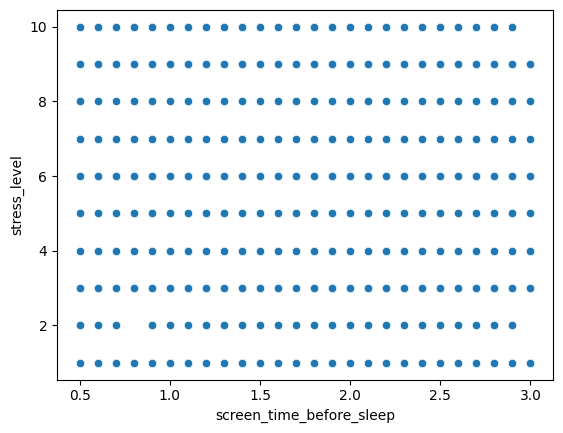

In [55]:
sns.scatterplot(data=df, x='screen_time_before_sleep', y='stress_level')

In [56]:
df['stress_level'].value_counts().sort_index()

stress_level
1     134
2     108
3     116
4     139
5     129
6     114
7     106
8     104
9     122
10    128
Name: count, dtype: int64

In [57]:
df['anxiety_level'].value_counts().sort_index()

anxiety_level
1     105
2     110
3     123
4     131
5     105
6     132
7     109
8     130
9     124
10    131
Name: count, dtype: int64

In [58]:
df['addiction_level'].value_counts().sort_index()

addiction_level
1     109
2     120
3     117
4     117
5     114
6     134
7     124
8     132
9     118
10    115
Name: count, dtype: int64